In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

import seaborn as sns
import matplotlib.pyplot as plt

import torch

#Make sure to path to wherever sherlock is located
sys.path.append('../..')
import sherlock as slk

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
slk.configs.show()
slk.configs.set_config('ntc_label', 'non-targeting')
print('\n')
slk.configs.show()
slk.configs.reset_config()
slk.configs.get_config('ntc_label')

ntc_label       = NTC
pert_key        = pert
treatment_key   = treatment
untreated_label = untreated


ntc_label       = non-targeting
pert_key        = pert
treatment_key   = treatment
untreated_label = untreated


'NTC'

In [5]:
data = slk.datasets.replogle()


In [6]:
perturbations = set(np.unique(data.obs[slk.configs.get_config('pert_key')].values))
print("Perturbations:", len(perturbations))

pathways = []
for pathway in data.uns['pathways'].values():
    pathways.append(set(pathway))
sum([len(pathways[i]) for i in range(len(pathways))])
print("Pathways:", len(pathways))

overlap = any(len(set(pathways[i]) & set(pathways[j])) > 0 for i in range(len(pathways)) for j in range(i + 1, len(pathways)))
print("Overlap exists between pathways:" if overlap else "No overlap between pathways.")

Perturbations: 682
Pathways: 8
No overlap between pathways.


In [7]:
slk.pp.treat_effect(
    data,
    label_col = 'pert',
    control_label = 'NTC',
    method = "perturbseq",
    inplace=True,
    key='treat_effect'
)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 681/681 [00:11<00:00, 61.06it/s]


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = slk.tl.run_single(data, batch_size=4096, shuffle=True, 
                            use_contrastive_jacobian=True,
                            use_de_align_loss=True, de_align_lambda=0.01,
                            num_workers=0, device=device)

Training VAE on cuda …


Epochs:   0%|                                                                                                 …

In [10]:
slk.tl.save_results(results, '../results/replogle_model.pth')

In [11]:
model = slk.tl.load_results('../results/replogle_model.pth')

In [12]:
slk.tl.eval_single(model, data, obsm_key="z", uns_key="results")

In [14]:
data.uns['results']['p2g']

array([[ 3.2113044 ,  4.100383  ,  1.8873891 , ...,  2.2529795 ,
         3.3833025 ,  2.5242615 ],
       [ 2.8851995 ,  3.9680388 ,  1.641619  , ...,  2.0232732 ,
         2.9674585 ,  1.8921363 ],
       [-0.38503426, -0.5549315 , -0.13873695, ...,  0.31234583,
        -0.02327888, -0.04607912],
       ...,
       [ 0.20159185,  0.23167324,  0.05895228, ..., -0.00421337,
         0.07493773,  0.02237017],
       [ 0.14675483,  0.14010122,  0.11112405, ...,  0.10680214,
         0.15993282,  0.21119988],
       [ 0.0131963 , -0.12170228, -0.10150814, ..., -0.16890286,
        -0.17413136, -0.08675376]], dtype=float32)

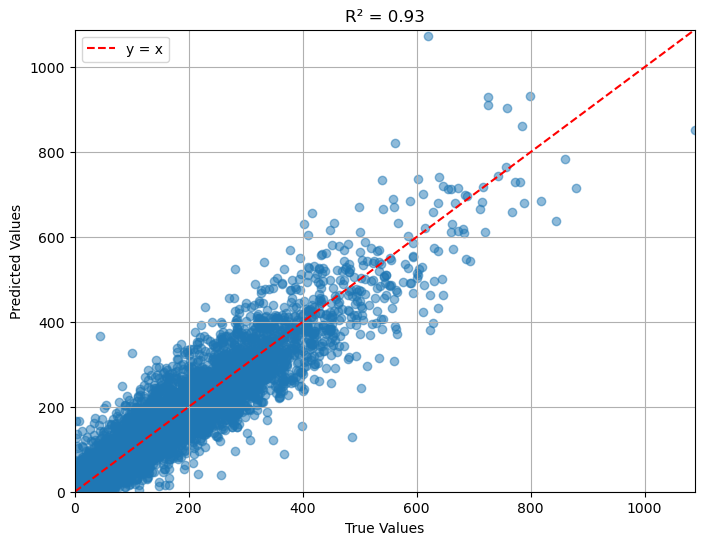

In [16]:
slk.pl.plot_r2(data)

/home/mingxuanzhang/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/mingxuanzhang/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


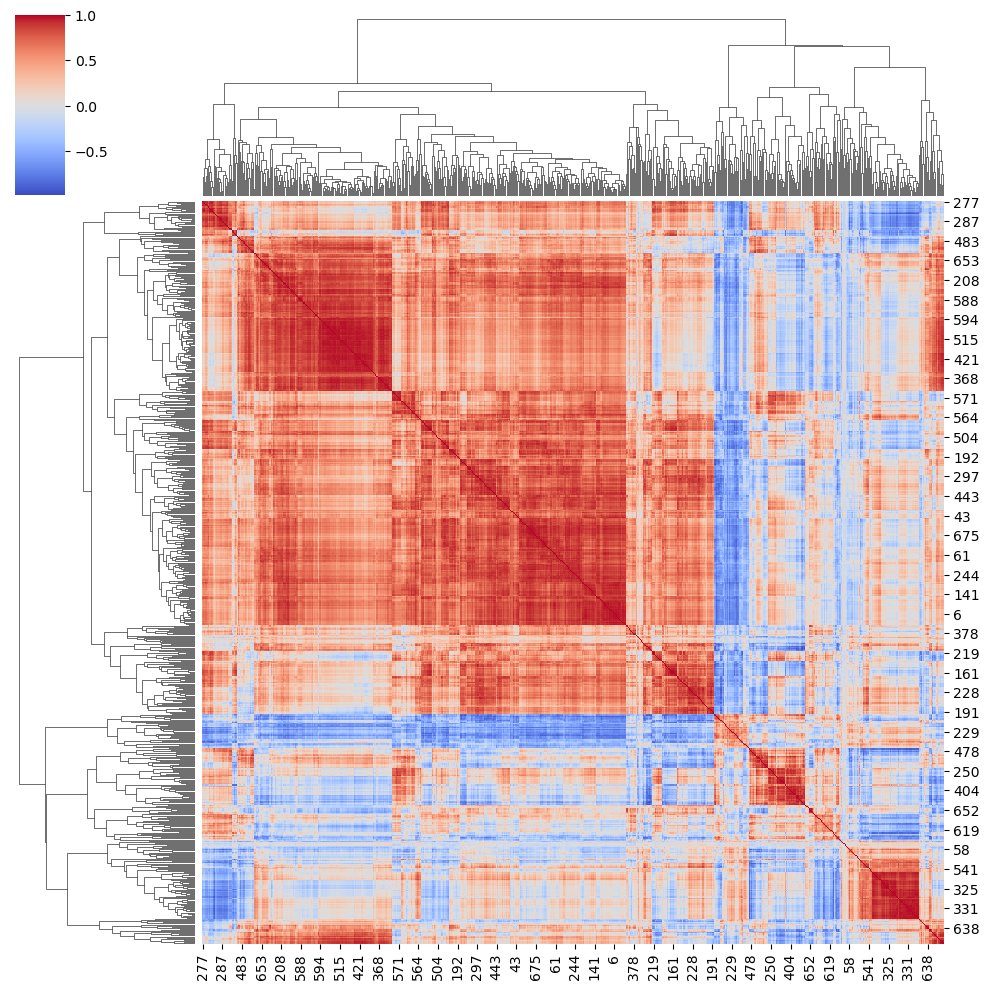

In [17]:
slk.pl.plot_corr(data)

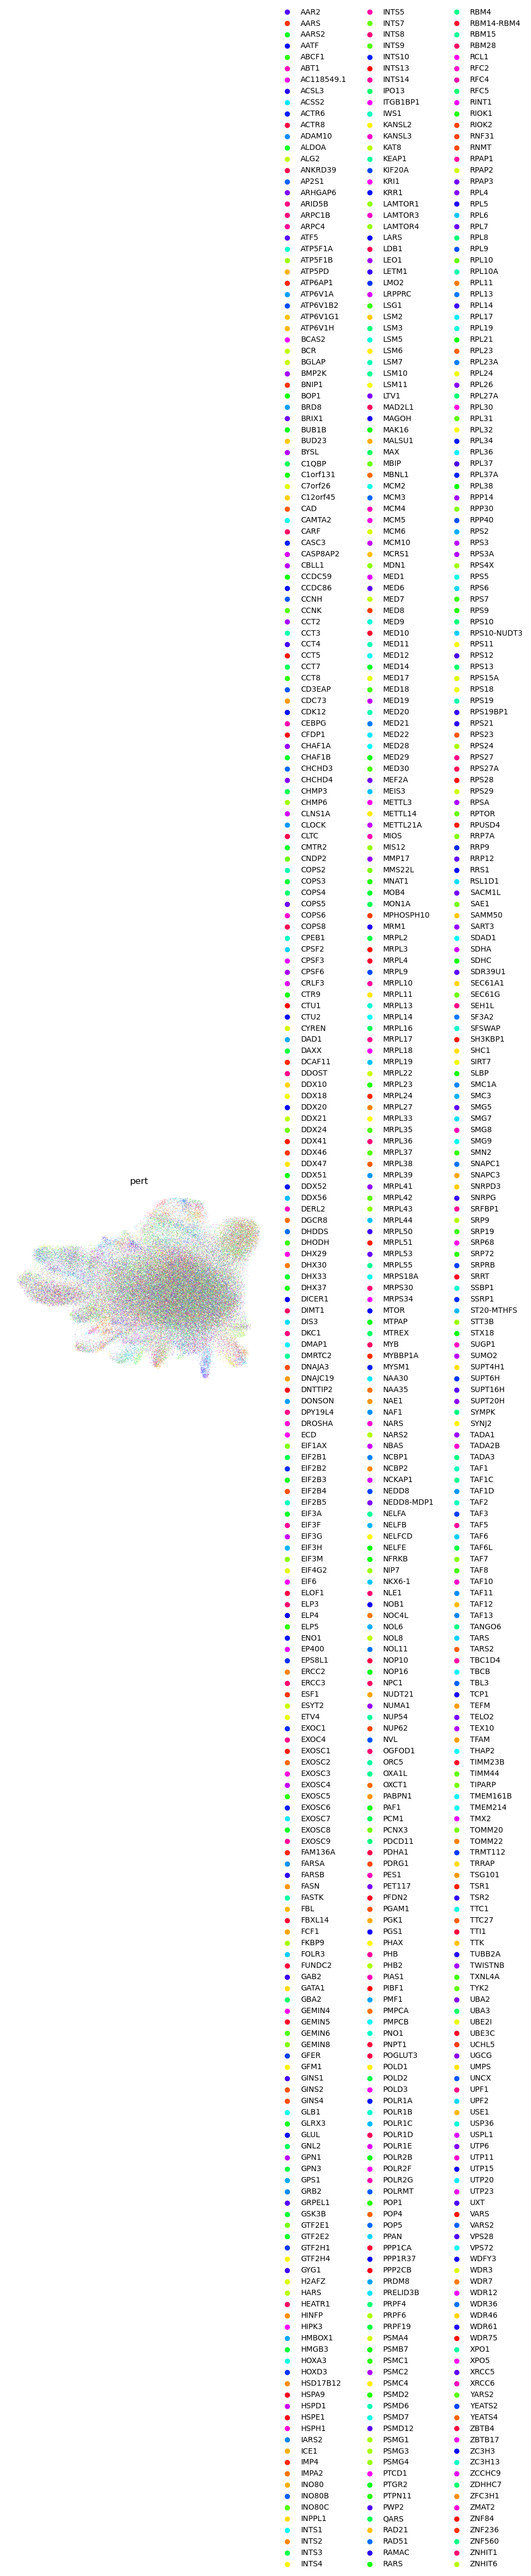

In [18]:
p_key = slk.configs.get_config('pert_key')
NTC = slk.configs.get_config('ntc_label')

sub = data[data.obs[p_key] != NTC]

sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
sc.tl.umap(sub)

import random
n_cats = sub.obs[p_key].nunique()
palette = sns.color_palette("hsv", n_colors=n_cats)
random.shuffle(palette)
sc.pl.umap(sub, color='pert', palette=palette, frameon=False)

In [19]:
zrc = data.uns['results']['z_rho_corr']

print(f"Spearman ρ = {zrc['spearman_r']:.3f}  (p = {zrc['spearman_p']:.1e})")
print(f" Pearson  r = {zrc['pearson_r']:.3f}  (p = {zrc['pearson_p']:.1e})") 

Spearman ρ = 0.398  (p = 0.0e+00)
 Pearson  r = 0.403  (p = 0.0e+00)


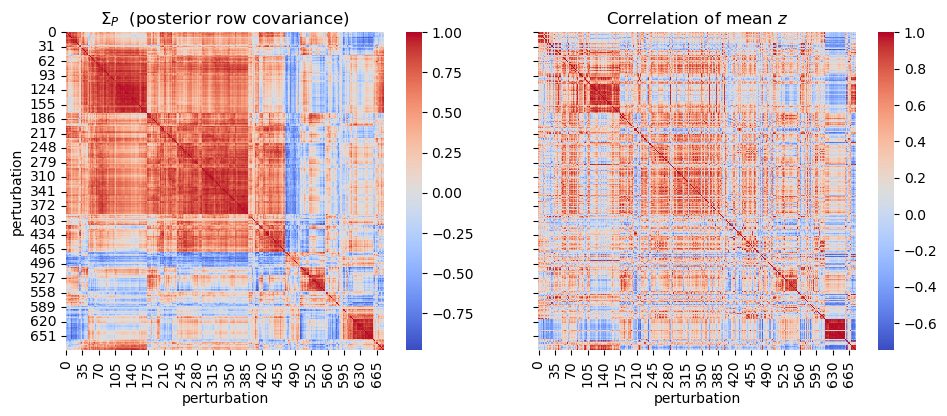

In [20]:
slk.pl.plot_zcorr(data)

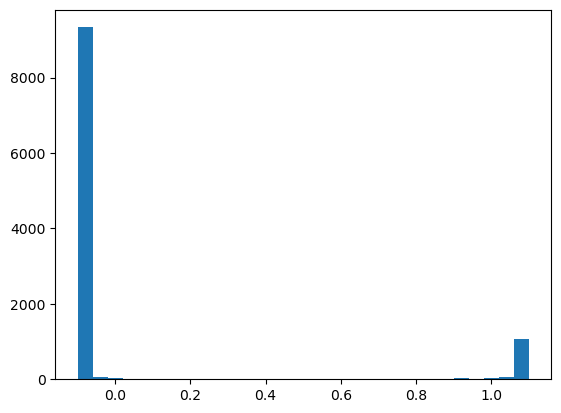

In [21]:
W = data.uns['results']['W']
plt.hist(W.flatten(), bins=30)
plt.show()

<Axes: >

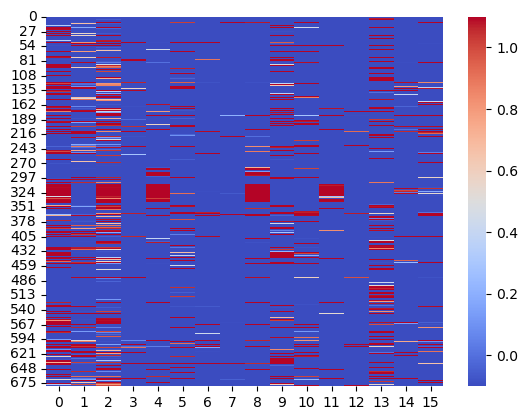

In [22]:
W_bin = (W > 0.5).astype(float)
sns.heatmap(W, cmap="coolwarm")

In [23]:
C = data.uns['results']['rho_corr']

#Specific subsetting for replogle. Otherwise just use C directly
all_genes = [gene for genes in data.uns['pathways'].values() for gene in genes]
dataset = slk.tl.PerturbMatchingDataset(data)
gene_ids = [dataset.perturbation_dict[g] for g in all_genes]
cov_subset = C[np.ix_(gene_ids, gene_ids)].clip(-1, 1)

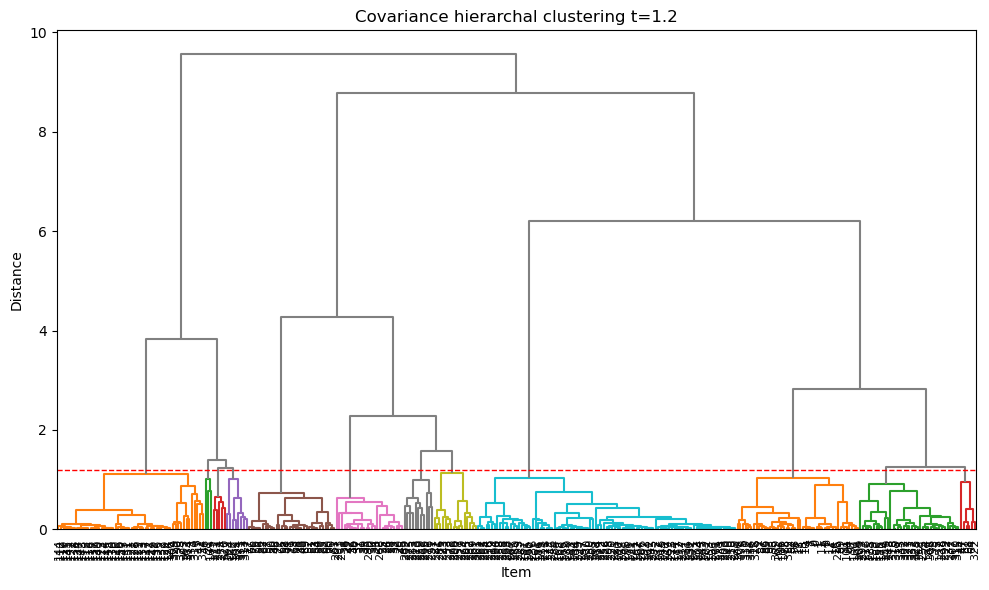

In [34]:
groups = slk.tl.cluster_rho(data, t=1.2, rho_corr=cov_subset, show=True)

In [35]:
#for a non subsetted data, pass in genes corresponding to idx ie dataset.perturbation_dict.keys()
named_groups = slk.tl.group2name(groups, all_genes)
named_groups

,group
ZC3H3,10
ZFC3H1,10
CAMTA2,10
DHX29,1
DIS3,10
...,...
SNRPG,11
TIPARP,1
TTC27,1
TXNL4A,11


## From here on out it is validation of replogle

In [36]:
from collections import Counter

# Flatten all genes from all pathways
#all_genes = [gene for genes in data.uns['pathways'].values() for gene in genes]

# Count how many times each gene appears
gene_counts = Counter(all_genes)

# Find genes that appear in more than one pathway
shared_genes = [gene for gene, count in gene_counts.items() if count > 1]

if shared_genes:
    print(f"⚠️ {len(shared_genes)} genes are shared across pathways:")
    print(shared_genes[:20])  # show first 20 for inspection
else:
    print("✅ Each gene appears in exactly one pathway.")


#pert df
pathway_genes = np.concatenate([i for i in list(data.uns['pathways'].values())])
pathway_genes = pathway_genes[pathway_genes != 'LSM5']
print(len(pathway_genes))
print(len(all_genes))
perts = pd.DataFrame(groups, index=all_genes, columns=['cluster'])
perts = perts.loc[pathway_genes]

#pathway df
gene_to_pathway = {
    gene: pathway
    for pathway, genes in data.uns['pathways'].items()
    for gene in genes if gene != 'LSM5'
}
pathway_df = pd.DataFrame.from_dict(gene_to_pathway, orient="index", columns=["cluster"])


perts = perts.drop(shared_genes, errors="ignore")
pathway_df = pathway_df.drop(shared_genes, errors="ignore")

print("After removal:")
print("perts size     :", perts.shape)
print("pathway_df size:", pathway_df.shape)

⚠️ 1 genes are shared across pathways:
['LSM5']
335
337
After removal:
perts size     : (335, 1)
pathway_df size: (335, 1)


In [37]:
pathway_df['gene'] = pathway_df.index.copy()
pathway_df.columns = ['pathway', 'gene']
pathway_df

,pathway,gene
ZC3H3,EXOSOME,ZC3H3
ZFC3H1,EXOSOME,ZFC3H1
CAMTA2,EXOSOME,CAMTA2
DHX29,EXOSOME,DHX29
DIS3,EXOSOME,DIS3
...,...,...
SNRPG,SPLICEOSOME,SNRPG
TIPARP,SPLICEOSOME,TIPARP
TTC27,SPLICEOSOME,TTC27
TXNL4A,SPLICEOSOME,TXNL4A


In [38]:
# Align on the same gene index
perts_aligned = perts.loc[pathway_df.index]

perts_aligned['gene'] = perts_aligned.index.copy()
perts_aligned

,cluster,gene
ZC3H3,10,ZC3H3
ZFC3H1,10,ZFC3H1
CAMTA2,10,CAMTA2
DHX29,1,DHX29
DIS3,10,DIS3
...,...,...
SNRPG,11,SNRPG
TIPARP,1,TIPARP
TTC27,1,TTC27
TXNL4A,11,TXNL4A


In [39]:
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
from sklearn.metrics.cluster import contingency_matrix
from scipy.optimize import linear_sum_assignment
from scipy.stats import hypergeom

try:
    from statsmodels.stats.multitest import multipletests
    _HAS_SM = True
except Exception:
    _HAS_SM = False


def align_and_summarize(
    clusters_df: pd.DataFrame,
    pathways_df: pd.DataFrame,
    gene_col: str = "gene",
    cluster_col: str = "cluster",
    pathway_col: str = "pathway",
    min_pathway_size: int = 1,
):
    # 1) Merge on gene
    df = pd.merge(
        clusters_df[[gene_col, cluster_col]],
        pathways_df[[gene_col, pathway_col]],
        on=gene_col,
        how="inner",
        validate="one_to_one"
    ).dropna(subset=[cluster_col, pathway_col]).copy()

    # Optional: filter tiny pathways to stabilize Hungarian/enrichment
    if min_pathway_size > 1:
        keep_path = df[pathway_col].value_counts()
        keep_path = keep_path[keep_path >= min_pathway_size].index
        df = df[df[pathway_col].isin(keep_path)].copy()

    # Cast to string for safe indexing
    y_true = df[pathway_col].astype(str).values
    y_pred = df[cluster_col].astype(str).values
    true_labels = np.unique(y_true)
    pred_labels = np.unique(y_pred)

    # 2) Contingency (rows=pathways, cols=clusters)
    C = pd.crosstab(df[pathway_col].astype(str), df[cluster_col].astype(str))
    contingency_df = C.reindex(index=true_labels, columns=pred_labels, fill_value=0)

    # 3) Hungarian alignment to maximize correct assignments (sum of diagonal)
    M = contingency_df.values
    row_ind, col_ind = linear_sum_assignment(M.max() - M)  # maximize
    mapping = {pred_labels[j]: true_labels[i] for i, j in zip(row_ind, col_ind)}

    # 4) Remap clusters → pathways and compute metrics
    mapped = np.array([mapping.get(cl, None) for cl in y_pred], dtype=object)
    is_match = mapped == y_true
    accuracy = float(is_match.mean())

    # Label-based external clustering metrics (label strings are fine)
    ari = adjusted_rand_score(y_true, y_pred)
    ami = adjusted_mutual_info_score(y_true, y_pred)

    # 5) Per-cluster purity & mapped target
    purity_rows = []
    for cl, g in df.groupby(cluster_col):
        majority = g[pathway_col].mode().iat[0]
        purity = (g[pathway_col] == majority).mean()
        purity_rows.append({
            "cluster": str(cl),
            "size": len(g),
            "mapped_pathway": mapping.get(str(cl), None),
            "purity": purity
        })
    purity_df = pd.DataFrame(purity_rows).sort_values("cluster").set_index("cluster")

    # 6) Normalized contingency for plotting
    contingency = contingency_df.copy()
    contingency_row_norm = contingency.div(contingency.sum(axis=1).replace(0, np.nan), axis=0)
    contingency_col_norm = contingency.div(contingency.sum(axis=0).replace(0, np.nan), axis=1)

    # 7) Pathway↔cluster enrichment (hypergeometric with FDR)
    #    N = total genes, K = pathway size, n = cluster size, k = overlap
    N = len(df)
    path_sizes = contingency.sum(axis=1)
    cl_sizes = contingency.sum(axis=0)
    records = []
    for p in contingency.index:
        K = int(path_sizes.loc[p])
        for c in contingency.columns:
            n = int(cl_sizes.loc[c])
            k = int(contingency.loc[p, c])
            # p-value: probability of ≥k overlap by chance
            pval = hypergeom.sf(k - 1, N, K, n) if k > 0 else 1.0
            records.append({"pathway": p, "cluster": c, "k": k, "K": K, "n": n, "N": N, "pval": float(pval)})

    enrich_df = pd.DataFrame(records)
    if _HAS_SM and len(enrich_df) > 0:
        enrich_df["qval"] = multipletests(enrich_df["pval"].values, method="fdr_bh")[1]
    else:
        # Bonferroni fallback
        m = max(len(enrich_df), 1)
        enrich_df["qval"] = np.minimum(enrich_df["pval"] * m, 1.0)

    # Signed/visual score: -log10(q)
    with np.errstate(divide="ignore"):
        enrich_df["neglog10q"] = -np.log10(np.clip(enrich_df["qval"].values, 1e-300, 1.0))

    # 8) Attach mapped labels into the merged table
    df["mapped_pathway"] = mapped
    df["is_match"] = is_match

    return {
        "merged": df[[gene_col, cluster_col, pathway_col, "mapped_pathway", "is_match"]].rename(
            columns={gene_col: "gene", cluster_col: "cluster", pathway_col: "pathway"}
        ),
        "mapping": mapping,
        "accuracy": accuracy,
        "ari": ari,
        "ami": ami,
        "purity_df": purity_df,
        "contingency": contingency,
        "contingency_row_norm": contingency_row_norm,
        "contingency_col_norm": contingency_col_norm,
        "enrichment": enrich_df,
    }


In [40]:
results = align_and_summarize(
    clusters_df=perts_aligned,          # gene↦cluster from covariance HC
    pathways_df=pathway_df,             # gene↦pathway ground truth
    gene_col="gene",
    cluster_col="cluster",
    pathway_col="pathway",
    min_pathway_size=1,                 # optional: filter tiny pathways
)

print("Best cluster→pathway mapping:")
for cl, pw in results["mapping"].items():
    print(f"  {cl} → {pw}")

print(f"\nGlobal alignment accuracy: {results['accuracy']:.3f}")
print(f"ARI: {results['ari']:.3f} | AMI: {results['ami']:.3f}\n")

print("Per-cluster purity:")
print(results["purity_df"])

Best cluster→pathway mapping:
  10 → EXOSOME
  6 → MEDIATOR_COMPLEX
  5 → MT_PROTEIN_TRANSLOCATION
  4 → NUCLEOTIDE_EXCISION_REPAIR
  1 → S39_RIBOSOMAL_UNIT
  9 → S40_RIBOSOMAL_UNIT
  8 → S60_RIBOSOMAL_UNIT
  11 → SPLICEOSOME

Global alignment accuracy: 0.639
ARI: 0.518 | AMI: 0.585

Per-cluster purity:
         size              mapped_pathway    purity
cluster                                            
1          54          S39_RIBOSOMAL_UNIT  0.777778
10         45                     EXOSOME  0.422222
11         35                 SPLICEOSOME  0.428571
12          6                        None  0.666667
2           3                        None  0.333333
3           5                        None  0.400000
4           8  NUCLEOTIDE_EXCISION_REPAIR  0.500000
5          32    MT_PROTEIN_TRANSLOCATION  1.000000
6          25            MEDIATOR_COMPLEX  0.800000
7          11                        None  0.909091
8          16          S60_RIBOSOMAL_UNIT  0.875000
9          95      

/var/tmp/ipykernel_19241/3854716668.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(all_cats))  # any qualitative map works


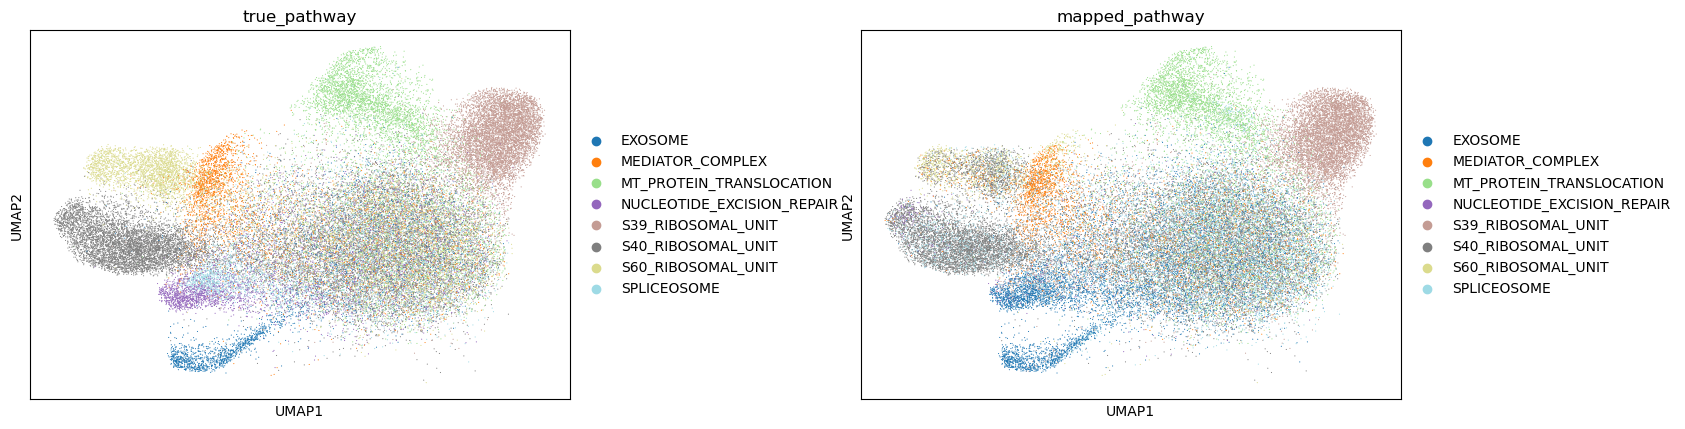

In [41]:
import numpy as np
import pandas as pd
from matplotlib.colors import to_hex
import matplotlib.pyplot as plt

# --- your existing setup ---
results_df = results['merged']
clustered_genes = results_df["gene"].unique()

z_sub = sub[sub.obs["pert"].isin(clustered_genes)].copy()

gene_to_true   = dict(zip(results_df["gene"], results_df["pathway"]))
gene_to_mapped = dict(zip(results_df["gene"], results_df["mapped_pathway"]))

z_sub.obs["true_pathway"]   = z_sub.obs["pert"].map(gene_to_true)
z_sub.obs["mapped_pathway"] = z_sub.obs["pert"].map(gene_to_mapped)

# Drop NA mapped rows
z_sub = z_sub[z_sub.obs["mapped_pathway"].notna() & (z_sub.obs["mapped_pathway"] != "NA")].copy()

# --- NEW: enforce identical palettes for both columns ---
# 1) Make both columns categorical with the SAME category set & order
true_vals   = pd.Index(z_sub.obs["true_pathway"].dropna().unique().astype(str))
mapped_vals = pd.Index(z_sub.obs["mapped_pathway"].dropna().unique().astype(str))
all_cats = pd.Index(np.unique(true_vals.union(mapped_vals)))  # sorted union

cat_dtype = pd.api.types.CategoricalDtype(categories=all_cats, ordered=False)
z_sub.obs["true_pathway"]   = z_sub.obs["true_pathway"].astype("string").astype(cat_dtype)
z_sub.obs["mapped_pathway"] = z_sub.obs["mapped_pathway"].astype("string").astype(cat_dtype)

# 2) Build a single color palette over all categories
cmap = plt.cm.get_cmap("tab20", len(all_cats))  # any qualitative map works
shared_palette = {cat: to_hex(cmap(i)) for i, cat in enumerate(all_cats)}

# 3) Write per-column color lists in each column's category order
true_order   = list(z_sub.obs["true_pathway"].cat.categories)
mapped_order = list(z_sub.obs["mapped_pathway"].cat.categories)

z_sub.uns["true_pathway_colors"]   = [shared_palette[c] for c in true_order]
z_sub.uns["mapped_pathway_colors"] = [shared_palette[c] for c in mapped_order]

# --- Plot (colors now matched across panels) ---
import scanpy as sc
sc.pl.umap(
    z_sub,
    color=["true_pathway", "mapped_pathway"],
    wspace=0.4,
)

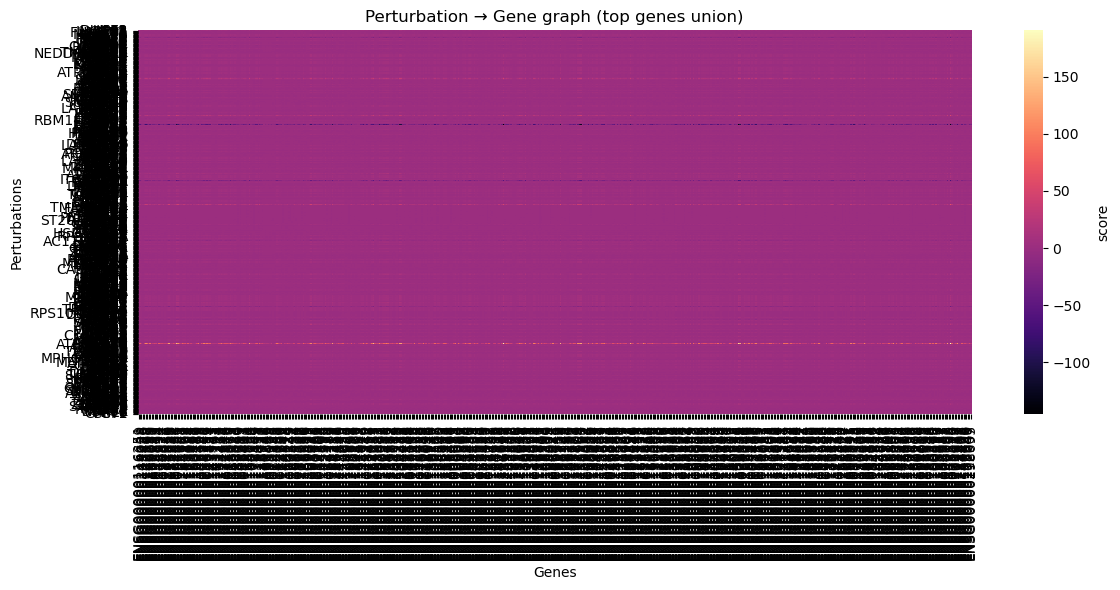

Row L1 mean±sd: 1391.356 2772.173
Row L2 mean±sd: 45.64026 93.116776
Top-1 fraction mean±sd: 0.003314 0.03797147


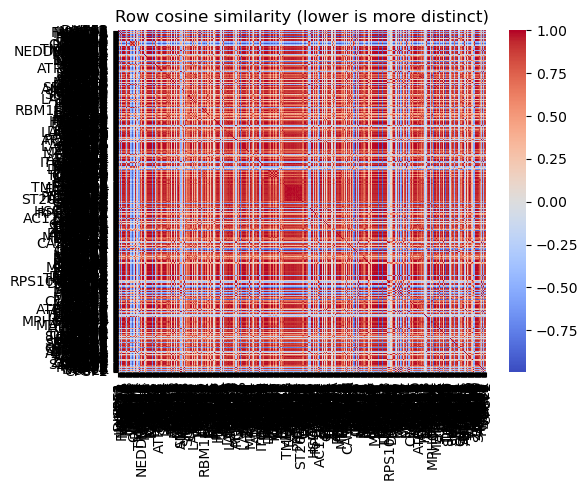

DE alignment (Spearman) over 680 shared perts: mean=0.015 ± 0.125


In [45]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
adata = data.copy()

# --- load graph ---
p2g = adata.uns["results"]["p2g"]  # shape: (n_perturbations, n_genes)
pert_labels = list(adata.uns["perturbation_dict"].keys()) if "perturbation_dict" in adata.uns else list(adata.obs['pert'].unique())
gene_names = list(adata.var_names)

# align sizes just in case
p2g = np.asarray(p2g)
n_p, n_g = p2g.shape
pert_labels = pert_labels[:n_p]

# --- global heatmap (top genes per perturbation for readability) ---
top_k = 25
top_idx = np.unique(np.hstack([np.argsort(-row)[:top_k] for row in p2g]))
p2g_top = p2g[:, top_idx]
genes_top = [gene_names[i] for i in top_idx]

plt.figure(figsize=(12, 6))
sns.heatmap(p2g_top, cmap="magma", yticklabels=pert_labels, xticklabels=genes_top, cbar_kws={"label": "score"})
plt.title("Perturbation → Gene graph (top genes union)")
plt.xlabel("Genes")
plt.ylabel("Perturbations")
plt.tight_layout()
plt.show()

# --- sparsity / concentration metrics ---
row_l1 = np.sum(np.abs(p2g), axis=1)
row_l2 = np.linalg.norm(p2g, axis=1)
row_top1_frac = np.max(p2g, axis=1) / (np.sum(p2g, axis=1) + 1e-8)
print("Row L1 mean±sd:", row_l1.mean(), row_l1.std())
print("Row L2 mean±sd:", row_l2.mean(), row_l2.std())
print("Top-1 fraction mean±sd:", row_top1_frac.mean(), row_top1_frac.std())

# --- overlap between perturbations (cosine similarity of rows) ---
normed = p2g / (np.linalg.norm(p2g, axis=1, keepdims=True) + 1e-8)
sim = normed @ normed.T
plt.figure(figsize=(6, 5))
sns.heatmap(sim, cmap="coolwarm", center=0, xticklabels=pert_labels, yticklabels=pert_labels)
plt.title("Row cosine similarity (lower is more distinct)")
plt.tight_layout()
plt.show()

# --- optional DE alignment if ground truth available in uns ---
if "treat_effect" in adata.uns:
    te = adata.uns["treat_effect"]
    if hasattr(te, "to_df"):
        te_df = te.to_df().reindex(columns=gene_names)
    else:
        te_df = pd.DataFrame(te.X, index=te.obs_names, columns=te.var_names).reindex(columns=gene_names)
    shared_perts = [p for p in pert_labels if p in te_df.index]
    if shared_perts:
        # rank-based agreement
        scores = []
        for p in shared_perts:
            i = pert_labels.index(p)
            pred_rank = pd.Series(p2g[i], index=gene_names).rank(ascending=False, method="average")
            truth_rank = te_df.loc[p].rank(ascending=False, method="average")
            r, _ = spearmanr(pred_rank, truth_rank)
            scores.append(r)
        print(f"DE alignment (Spearman) over {len(shared_perts)} shared perts: mean={np.nanmean(scores):.3f} ± {np.nanstd(scores):.3f}")
